In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import joblib

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("/content/online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nInformation:")
df.info()

Shape: (12330, 18)

Columns:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRate

In [4]:
# Missing Values

print(df.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [5]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 125


In [6]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


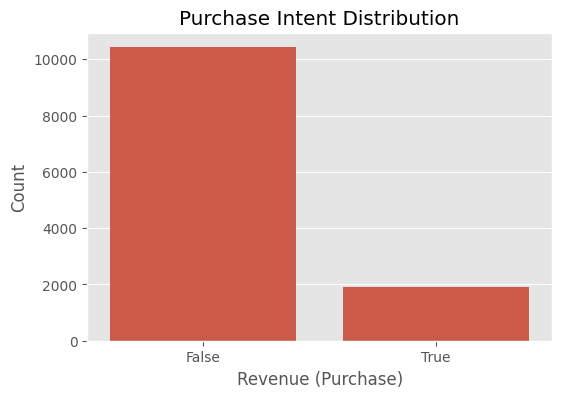

Revenue
False    10422
True      1908
Name: count, dtype: int64


In [7]:
# Target Variable Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='Revenue', data=df)

plt.title("Purchase Intent Distribution")
plt.xlabel("Revenue (Purchase)")
plt.ylabel("Count")

plt.show()

print(df['Revenue'].value_counts())

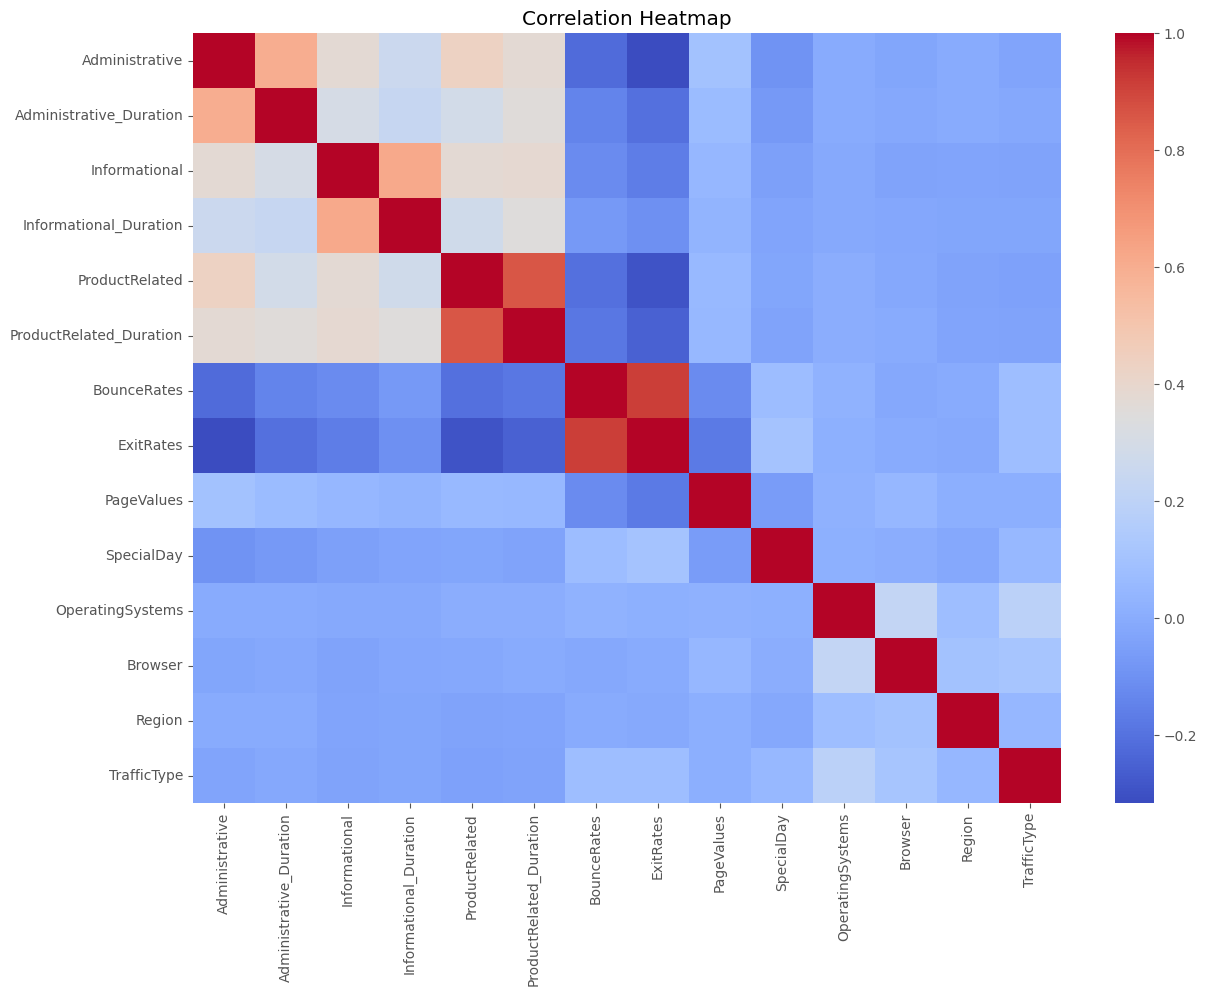

In [8]:
plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

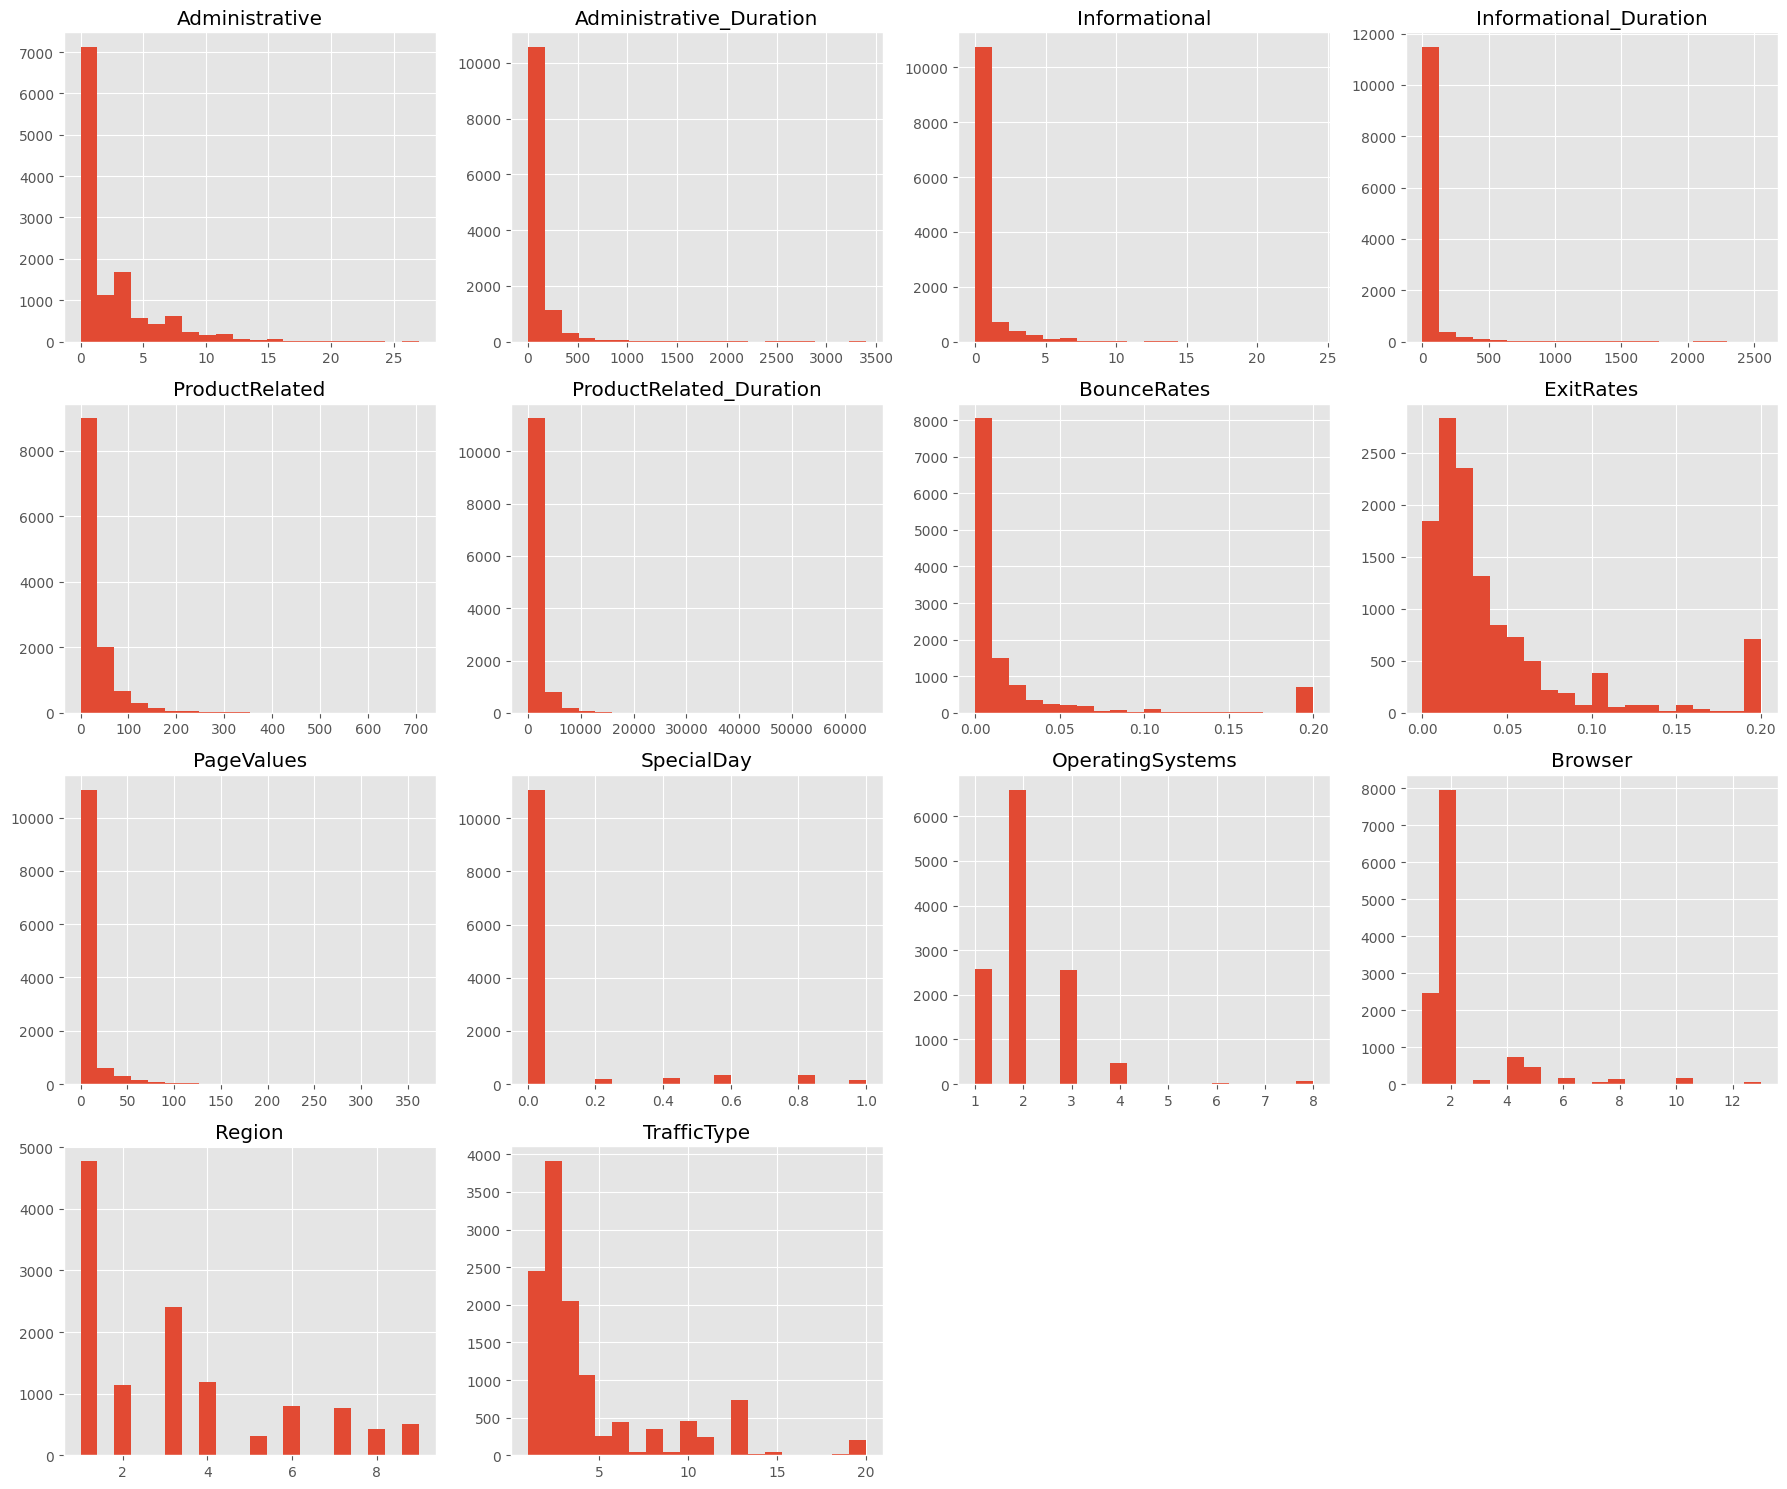

In [9]:
df.hist(figsize=(18,15), bins=20)

plt.tight_layout()

plt.show()

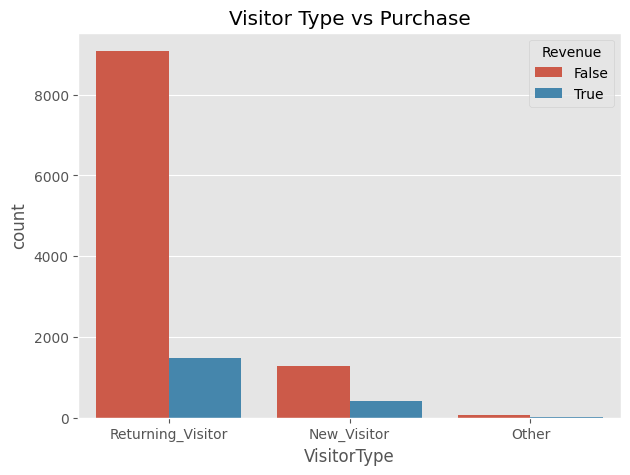

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='VisitorType',
    hue='Revenue',
    data=df
)

plt.title("Visitor Type vs Purchase")

plt.show()

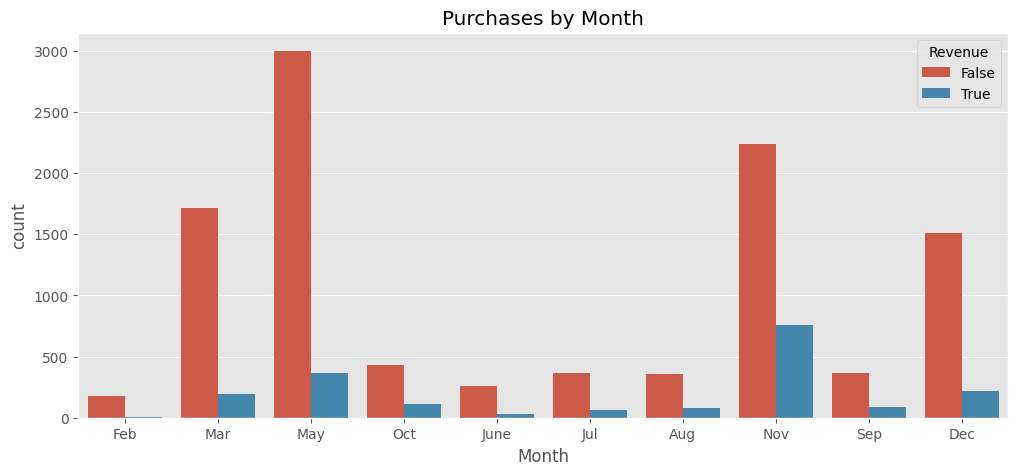

In [11]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='Month',
    hue='Revenue',
    data=df
)

plt.title("Purchases by Month")

plt.show()

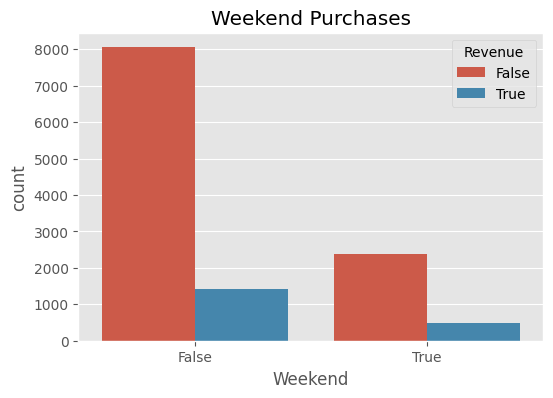

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Weekend',
    hue='Revenue',
    data=df
)

plt.title("Weekend Purchases")

plt.show()

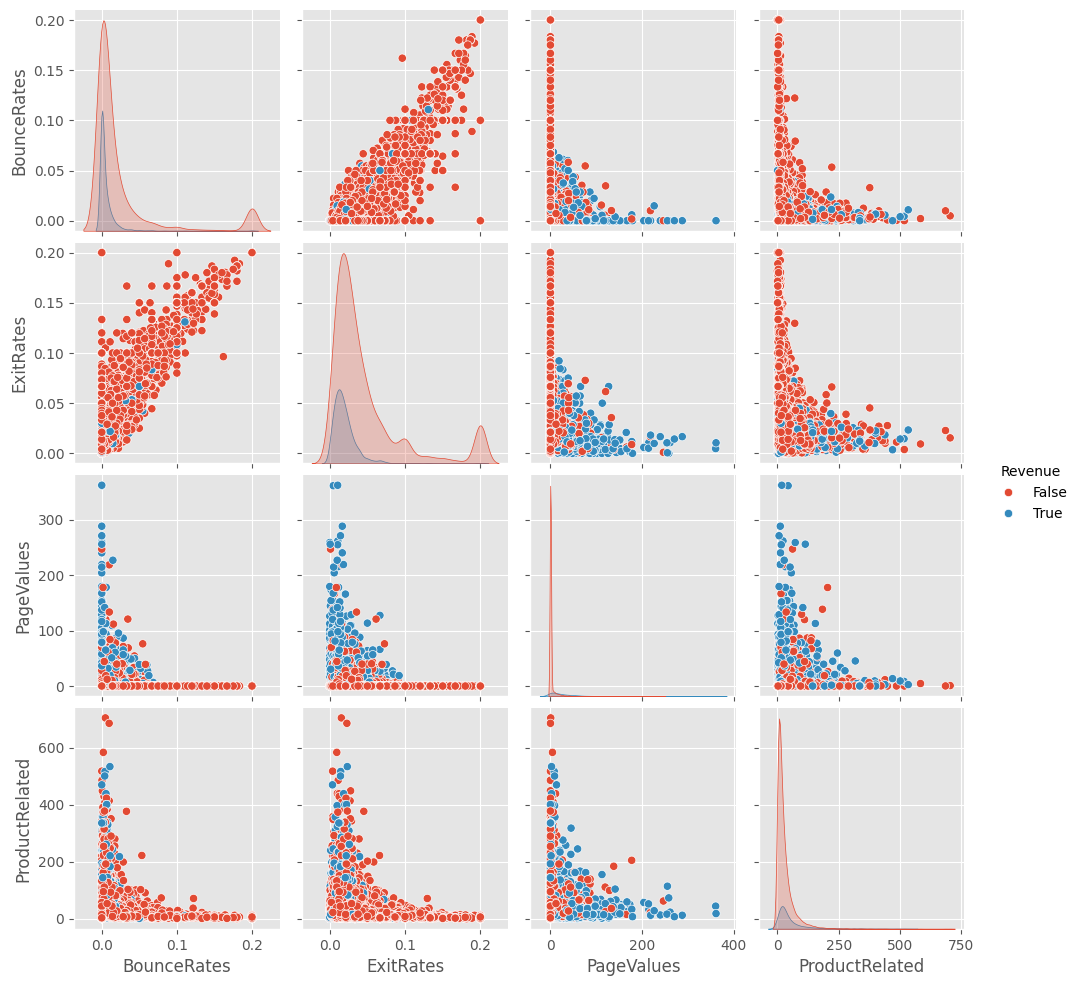

In [13]:
sns.pairplot(
    df[['BounceRates',
        'ExitRates',
        'PageValues',
        'ProductRelated',
        'Revenue']],
    hue='Revenue'
)

plt.show()

## Exploratory Data Analysis Findings

- Most visitors did not complete a purchase.
- Returning visitors tend to purchase more frequently than new visitors.
- Higher PageValues are associated with completed purchases.
- Weekend browsing shows a different purchase pattern compared to weekdays.
- Certain months have noticeably higher purchase rates.
- Bounce Rate and Exit Rate negatively correlate with purchasing behavior.

In [15]:
# ================================
# Feature Engineering
# ================================

# Total time spent across all page types
df['Total_Duration'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
)

# Total pages visited
df['Total_Pages'] = (
    df['Administrative'] +
    df['Informational'] +
    df['ProductRelated']
)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Total_Duration,Total_Pages
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False,0.000000,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False,64.000000,2
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False,0.000000,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False,2.666667,2
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False,627.500000,10


In [16]:
# ================================
# Label Encoding
# ================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    'Month',
    'VisitorType',
    'Weekend',
    'Revenue'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Total_Duration,Total_Pages
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0,0.000000,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0,64.000000,2
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0,0.000000,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0,2.666667,2
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0,627.500000,10


In [17]:
# ================================
# Features and Target
# ================================

X = df.drop('Revenue', axis=1)
y = df['Revenue']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (12330, 19)
Target Shape: (12330,)


In [18]:
# ================================
# Train Test Split
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(9864, 19)
(2466, 19)


In [19]:
# ================================
# Train Models
# ================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

print("Training Completed")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Completed


In [20]:
results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.884023,0.750000,0.376963,0.501742
Decision Tree,0.857664,0.536993,0.589005,0.561798
Random Forest,0.899432,0.724832,0.565445,0.635294
Gradient Boosting,0.899432,0.714744,0.583770,0.642651


In [21]:
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train, y_train)

prediction = best_model.predict(X_test)

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.72      0.57      0.64       382

    accuracy                           0.90      2466
   macro avg       0.82      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466



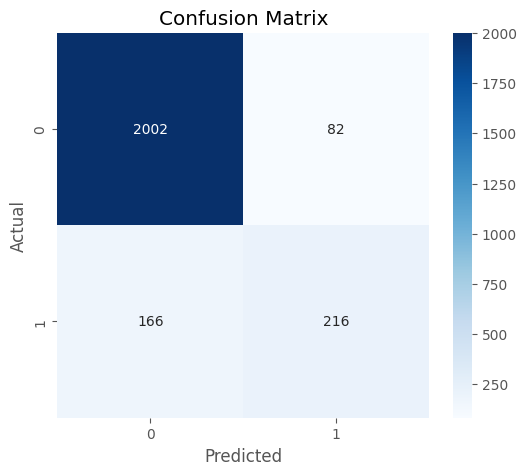

In [22]:
cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [23]:
probabilities = best_model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, probabilities)

print("ROC AUC Score:", roc)

ROC AUC Score: 0.9137538814804395


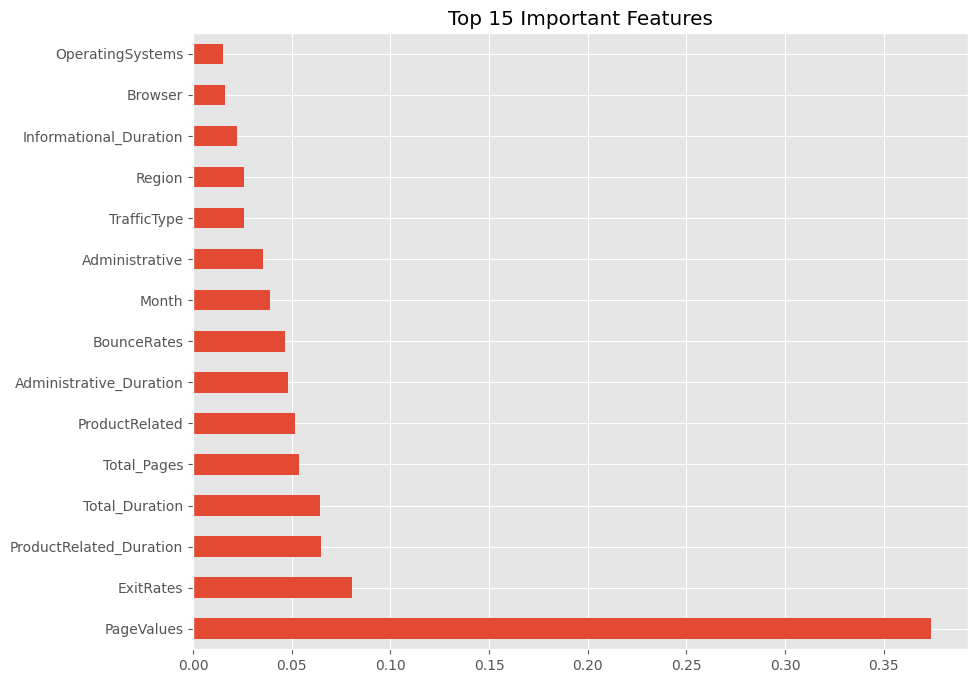

In [24]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(15).plot(kind='barh')

plt.title("Top 15 Important Features")

plt.show()

In [25]:
joblib.dump(best_model, "best_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [26]:
predictions = best_model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

prediction_df.to_csv(
    "predictions.csv",
    index=False
)

prediction_df.head()

,Actual,Predicted
4722,0,0
6835,0,0
5524,1,1
663,0,0
136,0,0


In [27]:
from sklearn.model_selection import GridSearchCV

# Parameters to test
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross Validation Score:
0.6562174756077309


In [28]:
best_rf = grid_search.best_estimator_

pred = best_rf.predict(X_test)

print(classification_report(y_test, pred))

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.74      0.57      0.64       382

    accuracy                           0.90      2466
   macro avg       0.83      0.77      0.79      2466
weighted avg       0.90      0.90      0.90      2466

Accuracy : 0.9022708840227088
Precision: 0.7389830508474576
Recall   : 0.5706806282722513
F1 Score : 0.6440177252584933


In [29]:
import joblib

joblib.dump(best_rf, "best_random_forest.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [30]:
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

prediction_df.to_csv("predictions.csv", index=False)

prediction_df.head()

,Actual,Predicted
4722,0,0
6835,0,0
5524,1,1
663,0,0
136,0,0


# Conclusion

This project developed a Customer Purchase Intent Prediction model using machine learning.

The dataset was cleaned, explored, and preprocessed before training multiple classification models.

The following algorithms were evaluated:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Random Forest achieved the best performance and was further improved using GridSearchCV for hyperparameter tuning.

Feature importance analysis showed that variables such as PageValues, ExitRates, ProductRelated, and Total_Duration had the greatest influence on predicting customer purchases.

The final tuned model was saved using Joblib and predictions were exported successfully.